## Agglomerative Hierarchical Clustering

### Setup and Data Preprocessing

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; import os; sys.stderr = open(os.devnull, 'w')
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt; import seaborn as sns  # Data processing and visualisation
import datetime as dt  # Datetime processing
from sklearn.preprocessing import MinMaxScaler  # Scaling
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster  # Hierarchical clustering

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding = 'cp1252'); df.sample(5)  # Load the data and look at it

,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4458,536783,SLEEPING CAT ERASERS,270,02-12-2010 15:19,0.16,15061.0,United Kingdom
84605,543399,"DECOUPAGE,GREETING CARD,",1,08-02-2011 11:07,0.83,NaN,United Kingdom
163301,550542,BIG DOUGHNUT FRIDGE MAGNETS,1,19-04-2011 11:37,8.29,NaN,United Kingdom
417136,572617,SET OF 12 MINI LOAF BAKING CASES,8,25-10-2011 11:52,0.83,18272.0,United Kingdom
70838,542103,POTTING SHED SEED ENVELOPES,12,25-01-2011 13:26,1.25,13198.0,United Kingdom


In [3]:
df.shape  # Size of the data

(541909, 7)

In [4]:
df.info()  # Details of features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   Description  540455 non-null  object 
 2   Quantity     541909 non-null  int64  
 3   InvoiceDate  541909 non-null  object 
 4   UnitPrice    541909 non-null  float64
 5   CustomerID   406829 non-null  float64
 6   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 28.9+ MB


In [5]:
df.dropna(subset = ['CustomerID'], inplace = True)  # Drop transactions where customer ID is missing
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]  # Remove cancelled transactions
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]  # Remove entries with corrupt values
df['CustomerID'] = df['CustomerID'].astype(int)  # Convert customer IDs to integer values

In [6]:
df.shape  # Size of data after cleaning

(397884, 7)

In [7]:
df.head()  # Look at the data again

,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom


In [8]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']  # Total price in pounds
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format = '%d-%m-%Y %H:%M')  # Process datetime information
final_date = df['InvoiceDate'].max() + dt.timedelta(days = 1)  # Reference date

In [9]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda date: (final_date - date.max()).days, 'InvoiceNo': 'nunique', 'TotalPrice': 'sum'})  # RFM
rfm.rename(columns = {'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'MonetaryValue'}, inplace = True)

In [10]:
rfm.shape  # Shape of the RFM table

(4338, 3)

In [11]:
rfm.sample(5)  # Look at the RFM data

,Recency,Frequency,MonetaryValue
CustomerID,,,
12883,25,4,703.47
14385,9,3,202.11
15350,373,1,115.65
16905,5,7,3102.43
17221,7,2,335.13


In [12]:
scaler = MinMaxScaler(); rfms = scaler.fit_transform(rfm); rfms  # Normalising features

array([[8.71313673e-01, 0.00000000e+00, 2.75443343e-01],
       [2.68096515e-03, 2.88461538e-02, 1.53683623e-02],
       [1.98391421e-01, 1.44230769e-02, 6.40069761e-03],
       ...,
       [1.87667560e-02, 4.80769231e-03, 6.22050635e-04],
       [8.04289544e-03, 7.21153846e-02, 7.46293026e-03],
       [1.12600536e-01, 9.61538462e-03, 6.54359438e-03]])

### Single Linkage

In [13]:
clustering_s = linkage(y = rfms, method = 'single')  # Cluster results / Linkage matrix
print('Indices of initial clusters - Linkage value - Size of new cluster')
clustering_s

Indices of initial clusters - Linkage value - Size of new cluster


array([[3.46900000e+03, 3.95800000e+03, 1.07065514e-07, 2.00000000e+00],
       [1.37700000e+03, 3.11400000e+03, 3.56885046e-07, 2.00000000e+00],
       [2.63400000e+03, 3.38400000e+03, 7.85147101e-07, 2.00000000e+00],
       ...,
       [0.00000000e+00, 8.67100000e+03, 2.66445167e-01, 4.33600000e+03],
       [3.26000000e+02, 1.87900000e+03, 3.94827261e-01, 2.00000000e+00],
       [8.67200000e+03, 8.67300000e+03, 4.09485855e-01, 4.33800000e+03]])

In [14]:
# Define a function that takes in the linkage matrix and presents the clustering results in a readable format
def results_clustering(linkage_matrix = None):
    # Convert the linkage matrix to a dataframe
    clustering_results = pd.DataFrame(data = linkage_matrix,
                                      columns = ['cluster_A', 'cluster_B', 'distance', 'size_new_cluster'],
                                      index = np.arange(1, len(rfms), 1))
    
    clustering_results.index.rename(name = 'Stage', inplace = True)  # Set the index of the dataframe to the stage or iteration number
    
    # Add a column that shows the indices of the new clusters as well
    temp = pd.Series(data = len(rfms) + np.arange(1, len(rfms), 1),
                     index = clustering_results.index,
                     name = 'new_cluster_index')
    
    clustering_results = pd.concat(objs = [clustering_results, temp], axis = 1)  # Add the header
    
    # Convert float values to integer values wherever applicable
    temp = ['cluster_A', 'cluster_B', 'size_new_cluster']
    clustering_results[temp] = clustering_results[temp].astype(dtype = int)
    
    return(clustering_results)

In [15]:
results_clustering(clustering_s)  # Clustering results

,cluster_A,cluster_B,distance,size_new_cluster,new_cluster_index
Stage,,,,,
1,3469,3958,1.070655e-07,2,4339
2,1377,3114,3.568850e-07,2,4340
3,2634,3384,7.851471e-07,2,4341
4,353,1260,2.176999e-06,2,4342
5,723,4247,2.319753e-06,2,4343
...,...,...,...,...,...
4333,3728,8669,2.318677e-01,4333,8671
4334,8659,8670,2.426346e-01,4335,8672
4335,0,8671,2.664452e-01,4336,8673


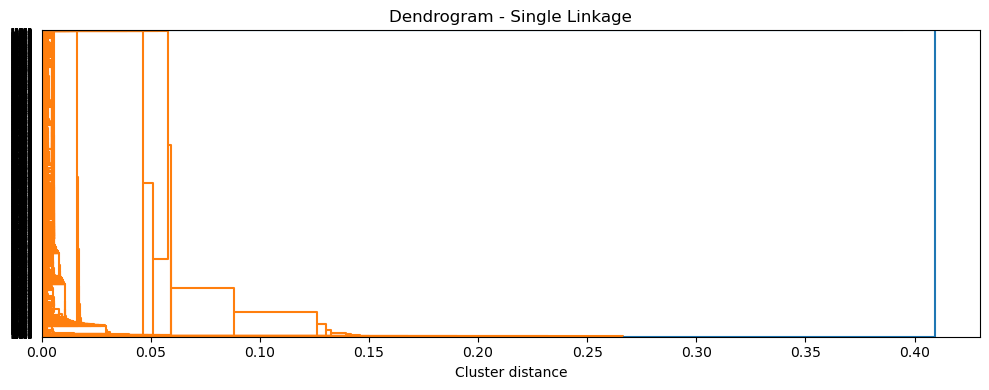

In [16]:
# Dendrogram for single linkage
plt.figure(figsize = (10, 4))
dendrogram(Z = clustering_s, orientation = 'right', labels = rfm.index)  # Dendrogram from clustering results
plt.title('Dendrogram - Single Linkage'); plt.xlabel('Cluster distance'); plt.tight_layout();

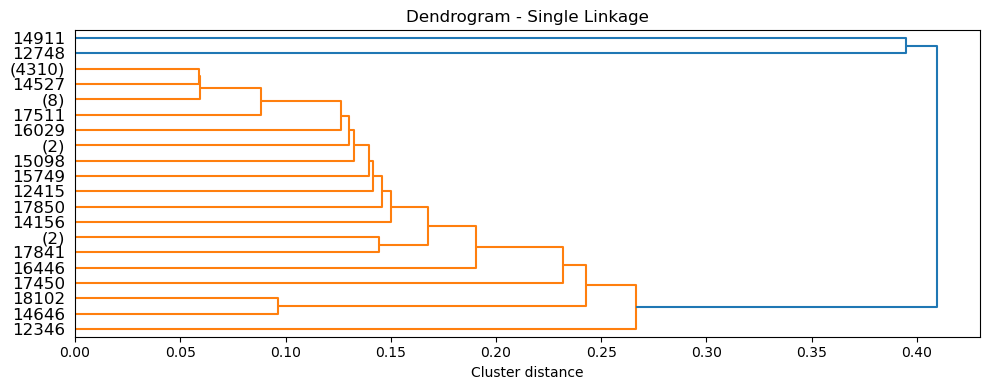

In [17]:
# Dendrogram for single linkage [truncated]
plt.figure(figsize = (10, 4))
dendrogram(Z = clustering_s, orientation = 'right', labels = rfm.index, p = 20, truncate_mode = 'lastp')   # Dendrogram
plt.title('Dendrogram - Single Linkage'); plt.xlabel('Cluster distance'); plt.tight_layout();

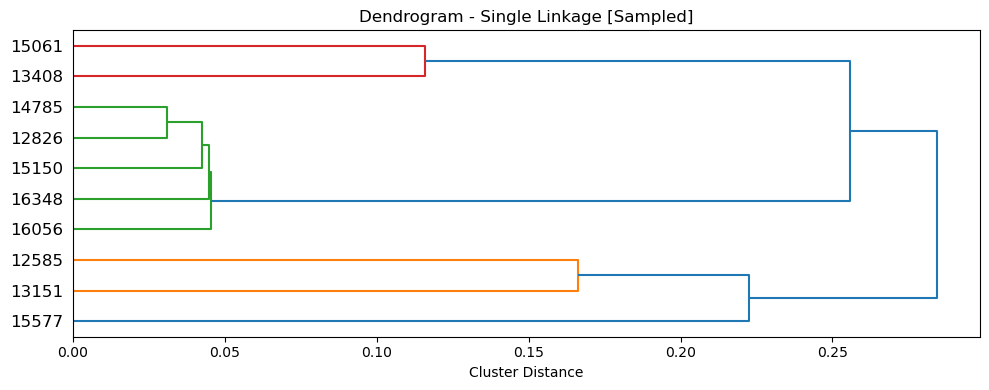

In [18]:
# Dendrogram for single linkage [sampled]
sample_indices = np.random.choice(rfms.shape[0], size = 10, replace = False)
sampled_rfms = rfms[sample_indices]
sampled_labels = [str(rfm.index[i]) for i in sample_indices]
plt.figure(figsize = (10, 4))
dendrogram(Z = linkage(sampled_rfms, method = 'single'), orientation = 'right', labels = sampled_labels)   # Dendrogram
plt.title('Dendrogram - Single Linkage [Sampled]'); plt.xlabel('Cluster Distance'); plt.tight_layout();

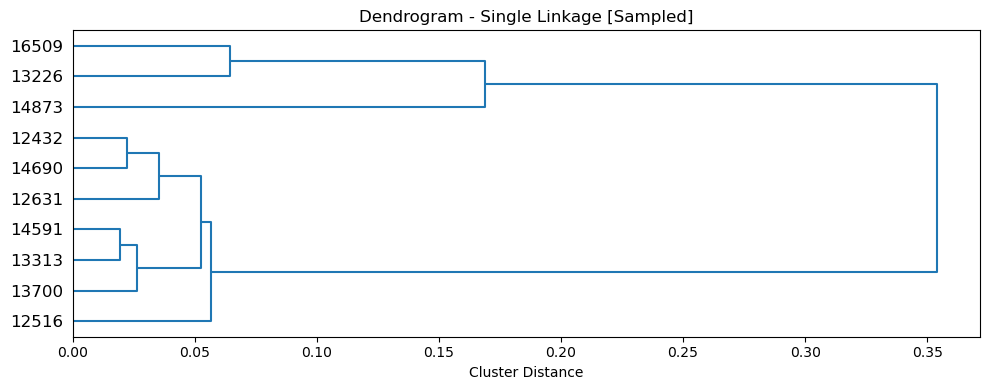

In [19]:
# Dendrogram for single linkage [sampled] [no coloring]
sample_indices = np.random.choice(rfms.shape[0], size = 10, replace = False)
sampled_rfms = rfms[sample_indices]
sampled_labels = [str(rfm.index[i]) for i in sample_indices]
plt.figure(figsize = (10, 4))
dendrogram(Z = linkage(sampled_rfms, method = 'single'), orientation = 'right', labels = sampled_labels, color_threshold = 0)   # Dendrogram
plt.title('Dendrogram - Single Linkage [Sampled]'); plt.xlabel('Cluster Distance'); plt.tight_layout();

In [20]:
t_distance = 0.01  # Distance thresholds (0.25, 0.1, 0.05, 0.01, 0.005)
fcluster_results = fcluster(Z = clustering_s, t = t_distance, criterion = 'distance'); fcluster_results  # Cluster labels
unique_values, counts = np.unique(fcluster_results, return_counts = True); value_counts = dict(zip(unique_values, counts))  # Labels and counts
print('The cluster labels for a distance threshold of {} are {}'.format(t_distance, fcluster_results))
print('The number of points is {} while the number of clusters is {}'.format(len(fcluster_results), len(unique_values)))
print('The cluster distribution is {}'.format(dict(zip(unique_values, counts))))

The cluster labels for a distance threshold of 0.01 are [161  66  66 ...  66  66  66]
The number of points is 4338 while the number of clusters is 163
The cluster distribution is {1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 117, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 4, 35: 1, 36: 2, 37: 3, 38: 2, 39: 1, 40: 1, 41: 1, 42: 2, 43: 1, 44: 1, 45: 1, 46: 1, 47: 2, 48: 1, 49: 1, 50: 3, 51: 2, 52: 2, 53: 2, 54: 4, 55: 2, 56: 2, 57: 2, 58: 2, 59: 478, 60: 1, 61: 1, 62: 2, 63: 16, 64: 12, 65: 2, 66: 3533, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 2, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1,

In [21]:
# Create a function to return clusters and their datapoints based on a distance threshold
def return_clusters(linkage_matrix = None, threshold = 0):
    fcluster_results = fcluster(Z = linkage_matrix, t = threshold, criterion = 'distance')  # Cluster labels

    # Obtaining the data point specifics for all the cluster labels
    cluster_items = {}
    for cluster_id in np.arange(1, fcluster_results.max() + 1, 1):
        cluster_items[cluster_id] = rfm.index[fcluster_results == cluster_id].tolist()
    
    return(cluster_items)

In [22]:
cluster_items = return_clusters(linkage_matrix = clustering_s, threshold = 0.01); cluster_items  # Clustering results for t = 0.01

{1: [14646],
 2: [18102],
 3: [13089],
 4: [15311],
 5: [17841],
 6: [12971],
 7: [14606],
 8: [15061],
 9: [17949],
 10: [14298],
 11: [13694],
 12: [13408],
 13: [13798],
 14: [16013],
 15: [16422],
 16: [15838],
 17: [17404],
 18: [12441,
  12515,
  12551,
  12686,
  12725,
  12734,
  12738,
  12785,
  12791,
  12797,
  12855,
  12967,
  13011,
  13033,
  13065,
  13108,
  13270,
  13295,
  13304,
  13369,
  13370,
  13747,
  13786,
  13807,
  13874,
  13922,
  13948,
  14082,
  14142,
  14237,
  14355,
  14373,
  14413,
  14437,
  14576,
  14589,
  14729,
  14813,
  14821,
  14932,
  15070,
  15160,
  15165,
  15180,
  15204,
  15221,
  15224,
  15279,
  15347,
  15350,
  15361,
  15363,
  15454,
  15460,
  15503,
  15562,
  15723,
  15789,
  15823,
  15880,
  15899,
  15922,
  15923,
  15945,
  15973,
  16048,
  16065,
  16125,
  16202,
  16270,
  16274,
  16499,
  16510,
  16565,
  16583,
  16658,
  16665,
  16679,
  16718,
  16727,
  16752,
  16754,
  16781,
  16795,
  16812,
  

In [23]:
len(cluster_items.keys())  # Check the number of clusters obtained

163

In [24]:
# Looking at resultant cluters by their sizes
sorted_cluster_items = dict(sorted(cluster_items.items(), key = lambda item: len(item[1]), reverse = True))
for cluster_id, customer_list in sorted_cluster_items.items(): print(f'Cluster {cluster_id}: {len(customer_list)} customers')

Cluster 66: 3533 customers
Cluster 59: 478 customers
Cluster 18: 117 customers
Cluster 63: 16 customers
Cluster 64: 12 customers
Cluster 34: 4 customers
Cluster 54: 4 customers
Cluster 37: 3 customers
Cluster 50: 3 customers
Cluster 36: 2 customers
Cluster 38: 2 customers
Cluster 42: 2 customers
Cluster 47: 2 customers
Cluster 51: 2 customers
Cluster 52: 2 customers
Cluster 53: 2 customers
Cluster 55: 2 customers
Cluster 56: 2 customers
Cluster 57: 2 customers
Cluster 58: 2 customers
Cluster 62: 2 customers
Cluster 65: 2 customers
Cluster 104: 2 customers
Cluster 1: 1 customers
Cluster 2: 1 customers
Cluster 3: 1 customers
Cluster 4: 1 customers
Cluster 5: 1 customers
Cluster 6: 1 customers
Cluster 7: 1 customers
Cluster 8: 1 customers
Cluster 9: 1 customers
Cluster 10: 1 customers
Cluster 11: 1 customers
Cluster 12: 1 customers
Cluster 13: 1 customers
Cluster 14: 1 customers
Cluster 15: 1 customers
Cluster 16: 1 customers
Cluster 17: 1 customers
Cluster 19: 1 customers
Cluster 20: 1 c

In [25]:
cluster_66 = rfm.loc[cluster_items[66], :]; cluster_66  # View original details of customer IDs in cluster 66

,Recency,Frequency,MonetaryValue
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12352,36,8,2506.04
12353,204,1,89.00
...,...,...,...
18278,74,1,173.90
18281,181,1,80.82
18282,8,2,178.05


In [26]:
cluster_66.describe().T.round(2)  # View descriptive summary of cluster 66

,count,mean,std,min,25%,50%,75%,max
Recency,3533.0,60.88,58.81,1.0,17.0,39.00,85.00,228.00
Frequency,3533.0,3.64,3.26,1.0,1.0,3.00,5.00,21.00
MonetaryValue,3533.0,1266.06,1415.97,6.2,344.0,738.96,1647.26,11054.96


In [27]:
cluster_59 = rfm.loc[cluster_items[59], :]; cluster_59.describe().T.round(2)  # View summary of cluster 59

,count,mean,std,min,25%,50%,75%,max
Recency,478.0,279.70,30.87,232.00,254.00,276.00,308.00,340.00
Frequency,478.0,1.30,0.68,1.00,1.00,1.00,1.00,6.00
MonetaryValue,478.0,386.88,367.88,3.75,155.36,300.06,457.66,3010.74


In [28]:
cluster_18 = rfm.loc[cluster_items[18], :]; cluster_18.describe().T.round(2)  # View summary of cluster 18

,count,mean,std,min,25%,50%,75%,max
Recency,117.0,365.89,6.40,351.0,361.0,366.0,372.0,374.0
Frequency,117.0,1.05,0.22,1.0,1.0,1.0,1.0,2.0
MonetaryValue,117.0,277.13,261.32,15.0,145.0,230.4,326.0,2002.4


In [29]:
# Clustering results for t = 0.005
cluster_items = return_clusters(linkage_matrix = clustering_s, threshold = 0.005)
sorted_cluster_items = dict(sorted(cluster_items.items(), key = lambda item: len(item[1]), reverse = True))
for cluster_id, customer_list in sorted_cluster_items.items(): print(f'Cluster {cluster_id}: {len(customer_list)} customers')

Cluster 304: 2302 customers
Cluster 92: 210 customers
Cluster 312: 208 customers
Cluster 174: 146 customers
Cluster 289: 107 customers
Cluster 286: 85 customers
Cluster 177: 78 customers
Cluster 20: 67 customers
Cluster 176: 63 customers
Cluster 91: 58 customers
Cluster 96: 58 customers
Cluster 88: 45 customers
Cluster 18: 40 customers
Cluster 310: 40 customers
Cluster 84: 33 customers
Cluster 95: 33 customers
Cluster 292: 32 customers
Cluster 90: 20 customers
Cluster 179: 20 customers
Cluster 285: 17 customers
Cluster 275: 12 customers
Cluster 326: 11 customers
Cluster 19: 9 customers
Cluster 262: 8 customers
Cluster 336: 8 customers
Cluster 215: 7 customers
Cluster 256: 7 customers
Cluster 254: 6 customers
Cluster 214: 5 customers
Cluster 242: 5 customers
Cluster 276: 5 customers
Cluster 287: 5 customers
Cluster 298: 5 customers
Cluster 139: 4 customers
Cluster 252: 4 customers
Cluster 253: 4 customers
Cluster 260: 4 customers
Cluster 261: 4 customers
Cluster 323: 4 customers
Cluster

In [30]:
cluster_304 = rfm.loc[cluster_items[304], :]; cluster_304.describe().T.round(2)  # View summary of cluster 304

,count,mean,std,min,25%,50%,75%,max
Recency,2302.0,31.36,23.27,1.0,11.00,26.0,50.00,83.00
Frequency,2302.0,3.37,2.52,1.0,1.00,3.0,4.00,16.00
MonetaryValue,2302.0,1089.77,994.31,6.2,363.91,757.9,1488.58,6328.05


In [31]:
cluster_92 = rfm.loc[cluster_items[92], :]; cluster_92.describe().T.round(2)  # View summary of cluster 92

,count,mean,std,min,25%,50%,75%,max
Recency,210.0,251.35,11.74,232.00,241.00,252.50,262.00,271.00
Frequency,210.0,1.25,0.50,1.00,1.00,1.00,1.00,3.00
MonetaryValue,210.0,364.93,296.74,12.75,171.01,298.86,426.69,1829.04


In [32]:
cluster_312 = rfm.loc[cluster_items[312], :]; cluster_312.describe().T.round(2)  # View summary of cluster 312

,count,mean,std,min,25%,50%,75%,max
Recency,208.0,96.11,8.50,84.0,88.00,95.00,106.00,111.00
Frequency,208.0,2.09,1.18,1.0,1.00,2.00,3.00,6.00
MonetaryValue,208.0,704.90,547.86,13.3,304.94,569.29,984.34,2881.02


### Complete Linkage

In [33]:
clustering_c = linkage(y = rfms, method = 'complete')  # Cluster results
print('Indices of initial clusters - Linkage value - Size of new cluster')
clustering_c

Indices of initial clusters - Linkage value - Size of new cluster


array([[3.46900000e+03, 3.95800000e+03, 1.07065514e-07, 2.00000000e+00],
       [1.37700000e+03, 3.11400000e+03, 3.56885046e-07, 2.00000000e+00],
       [2.63400000e+03, 3.38400000e+03, 7.85147101e-07, 2.00000000e+00],
       ...,
       [8.63100000e+03, 8.66600000e+03, 1.09605933e+00, 4.00000000e+00],
       [8.67100000e+03, 8.67200000e+03, 1.14723594e+00, 3.21500000e+03],
       [8.66900000e+03, 8.67300000e+03, 1.47909818e+00, 4.33800000e+03]])

In [34]:
results_clustering(clustering_c)  # Clustering results

,cluster_A,cluster_B,distance,size_new_cluster,new_cluster_index
Stage,,,,,
1,3469,3958,1.070655e-07,2,4339
2,1377,3114,3.568850e-07,2,4340
3,2634,3384,7.851471e-07,2,4341
4,353,1260,2.176999e-06,2,4342
5,723,4247,2.319753e-06,2,4343
...,...,...,...,...,...
4333,8655,8667,7.056682e-01,3202,8671
4334,8668,8670,8.022194e-01,3211,8672
4335,8631,8666,1.096059e+00,4,8673


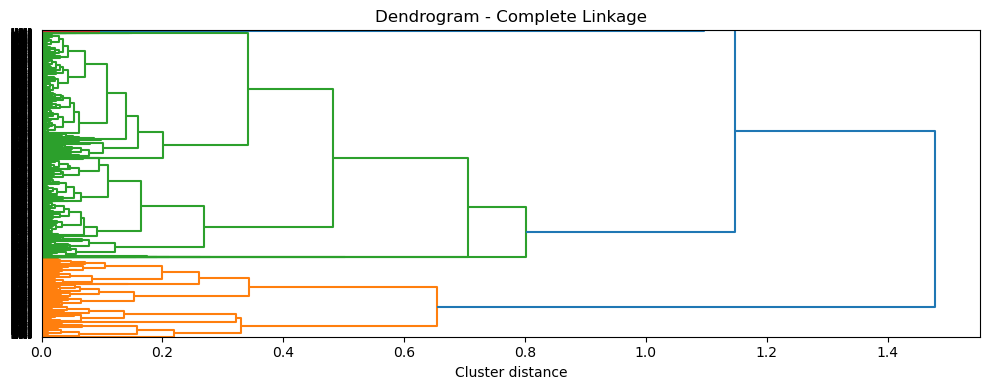

In [35]:
# Dendrogram for complete linkage
plt.figure(figsize = (10, 4))
dendrogram(Z = clustering_c, orientation = 'right', labels = rfm.index)  # Dendrogram
plt.title('Dendrogram - Complete Linkage'); plt.xlabel('Cluster distance'); plt.tight_layout();

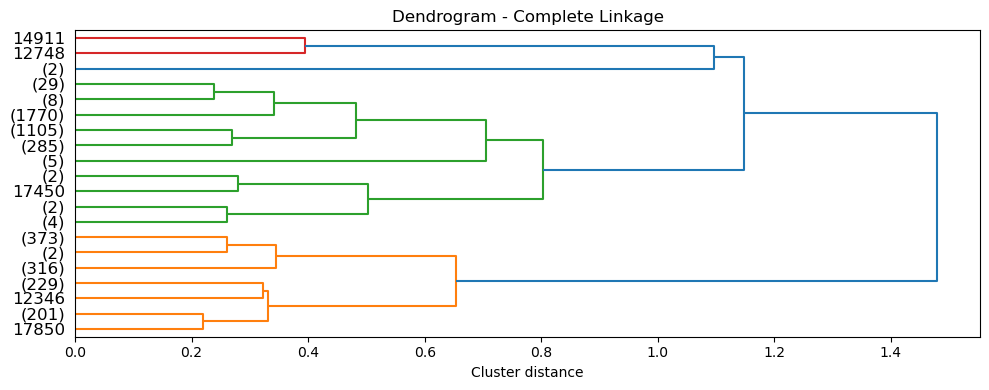

In [36]:
# Dendrogram for complete linkage [truncated]
plt.figure(figsize = (10, 4))
dendrogram(Z = clustering_c, orientation = 'right', labels = rfm.index, p = 20, truncate_mode = 'lastp')   # Dendrogram
plt.title('Dendrogram - Complete Linkage'); plt.xlabel('Cluster distance'); plt.tight_layout();

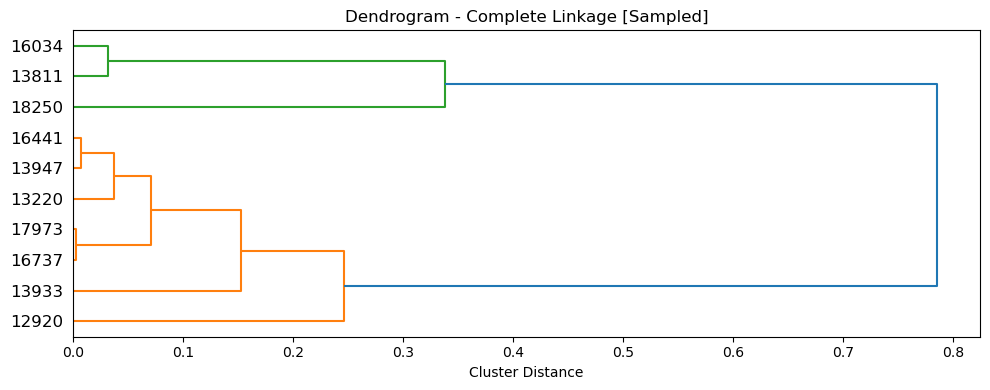

In [37]:
# Dendrogram for complete linkage [sampled]
sample_indices = np.random.choice(rfms.shape[0], size = 10, replace = False)
sampled_rfms = rfms[sample_indices]
sampled_labels = [str(rfm.index[i]) for i in sample_indices]
plt.figure(figsize = (10, 4))
dendrogram(Z = linkage(sampled_rfms, method = 'complete'), orientation = 'right', labels = sampled_labels)   # Dendrogram
plt.title('Dendrogram - Complete Linkage [Sampled]'); plt.xlabel('Cluster Distance'); plt.tight_layout();

In [38]:
t_distance = 0.1  # Distance threshold (1, 0.5, 0.2, 0.1)
fcluster_results = fcluster(Z = clustering_c, t = t_distance, criterion = 'distance'); fcluster_results  # Cluster labels
unique_values, counts = np.unique(fcluster_results, return_counts = True); value_counts = dict(zip(unique_values, counts))  # Labels and counts
print('The cluster labels for a distance threshold of {} are {}'.format(t_distance, fcluster_results))
print('The number of points is {} while the number of clusters is {}'.format(len(fcluster_results), len(unique_values)))
print('The cluster distribution is {}'.format(dict(zip(unique_values, counts))))

The cluster labels for a distance threshold of 0.1 are [ 6 33 27 ... 33 30 26]
The number of points is 4338 while the number of clusters is 41
The cluster distribution is {1: 118, 2: 83, 3: 1, 4: 114, 5: 115, 6: 1, 7: 133, 8: 183, 9: 1, 10: 1, 11: 173, 12: 100, 13: 100, 14: 3, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 2, 22: 2, 23: 1, 24: 112, 25: 173, 26: 494, 27: 328, 28: 283, 29: 8, 30: 194, 31: 46, 32: 109, 33: 597, 34: 816, 35: 4, 36: 4, 37: 3, 38: 26, 39: 2, 40: 1, 41: 1}


In [39]:
# Clustering results for t = 0.1
cluster_items = return_clusters(linkage_matrix = clustering_c, threshold = 0.1)
sorted_cluster_items = dict(sorted(cluster_items.items(), key = lambda item: len(item[1]), reverse = True))
for cluster_id, customer_list in sorted_cluster_items.items(): print(f'Cluster {cluster_id}: {len(customer_list)} customers')

Cluster 34: 816 customers
Cluster 33: 597 customers
Cluster 26: 494 customers
Cluster 27: 328 customers
Cluster 28: 283 customers
Cluster 30: 194 customers
Cluster 8: 183 customers
Cluster 11: 173 customers
Cluster 25: 173 customers
Cluster 7: 133 customers
Cluster 1: 118 customers
Cluster 5: 115 customers
Cluster 4: 114 customers
Cluster 24: 112 customers
Cluster 32: 109 customers
Cluster 12: 100 customers
Cluster 13: 100 customers
Cluster 2: 83 customers
Cluster 31: 46 customers
Cluster 38: 26 customers
Cluster 29: 8 customers
Cluster 35: 4 customers
Cluster 36: 4 customers
Cluster 14: 3 customers
Cluster 37: 3 customers
Cluster 21: 2 customers
Cluster 22: 2 customers
Cluster 39: 2 customers
Cluster 3: 1 customers
Cluster 6: 1 customers
Cluster 9: 1 customers
Cluster 10: 1 customers
Cluster 15: 1 customers
Cluster 16: 1 customers
Cluster 17: 1 customers
Cluster 18: 1 customers
Cluster 19: 1 customers
Cluster 20: 1 customers
Cluster 23: 1 customers
Cluster 40: 1 customers
Cluster 41: 

In [40]:
# Function to summarise all clusters
def all_cluster_summary(all_clusters, rfm_df, top_n = 5):
    summaries = []  # Store all cluster summaries

    # For each cluster, summarise and store RFM values
    for cluster_id, customer_indices in cluster_items.items():
        cluster_df = rfm_df.loc[customer_indices]
        summary = cluster_df.describe().T.round(2)
        summary.index.name = 'RFM'
        summary['Cluster'] = cluster_id
        summary = summary.set_index('Cluster', append = True).swaplevel()
        summaries.append(summary)
        
    result = pd.concat(summaries).sort_values(by = 'count', ascending = False)
    
    return result.head(top_n * 3)

In [41]:
all_cluster_summary(cluster_items, rfm, 5)

count     mean      std    min     25%      50%  \
Cluster RFM                                                              
34      MonetaryValue  816.0  1089.34  1051.28  20.80  371.96   776.16   
        Frequency      816.0     3.18     1.93   1.00    2.00     3.00   
        Recency        816.0    23.23     6.42  11.00   18.00    23.00   
33      Recency        597.0     6.27     3.46   1.00    3.00     6.00   
        MonetaryValue  597.0  1568.47  1488.45  41.99  553.44  1191.13   
        Frequency      597.0     4.35     2.49   1.00    2.00     4.00   
26      MonetaryValue  494.0  1151.08  1695.59   6.90  324.16   657.26   
        Frequency      494.0     2.98     2.38   1.00    1.00     2.00   
        Recency        494.0    46.27     6.40  35.00   40.00    46.00   
27      Recency        328.0    65.27     4.87  56.00   61.00    65.00   
        Frequency      328.0     2.98     2.14   1.00    1.00     2.00   
        MonetaryValue  328.0  1173.72  1366.89   6.20  359.56   692.15   
28      Recency        283.0    82.67     6.59  66.00   78.00    82.00   
        Frequency      283.0     2.40     2.32   1.00    1.00     2.00   
        MonetaryValue  283.0   969.58  1219.82  13.30  320.59   620.40   

                           75%       max  
Cluster RFM                               
34      MonetaryValue  1419.16   6748.80  
        Frequency         4.00      9.00  
        Recency          29.00     36.00  
33      Recency           9.00     13.00  
        MonetaryValue  2160.70  13375.87  
        Frequency         6.00     10.00  
26      MonetaryValue  1436.47  21279.29  
        Frequency         4.00     12.00  
        Recency          52.00     58.00  
27      Recency          70.00     75.00  
        Frequency         4.00     11.00  
        MonetaryValue  1561.38  11581.80  
28      Recency          88.00     96.00  
        Frequency         3.00     17.00  
        MonetaryValue  1094.51  11072.67